# Imports

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import torchvision.transforms as transforms
import torch.nn.utils.spectral_norm as spectral_norm
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder


# Parameters

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256
nz = 100
lr = 0.0002
beta1 = 0.5
epochs = 200
data_dir = "trafic_32"

# Data transformation and dataloader setup

In [3]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = ImageFolder(root=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Generator architecture

In [4]:
class Generator(nn.Module):
    def __init__(self, nz):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Discriminator architecture

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            spectral_norm(nn.Conv2d(3, 64, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            
            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            
            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            
            spectral_norm(nn.Conv2d(256, 1, 4, 1, 0, bias=False)),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

# Custom weights initialization and optimizer setup

In [6]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG = Generator(nz).to(device)
netD = Discriminator().to(device)

netG_path = "generator.pth"
netD_path = "discriminator.pth"

if os.path.exists(netG_path) and os.path.exists(netD_path):
    print("Loading pre-trained models from disk...")
    netG.load_state_dict(torch.load(netG_path, map_location=device))
    netD.load_state_dict(torch.load(netD_path, map_location=device))
    train_model = False
else:
    print("Pre-trained models not found. Initializing weights for training...")
    netG.apply(weights_init)
    netD.apply(weights_init)
    train_model = True

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

Loading pre-trained models from disk...


# Training loop

In [7]:
if train_model:
    print("Starting training loop...")
    for epoch in range(epochs):
        for i, data in enumerate(dataloader, 0):
            netD.zero_grad()
            real_cpu = data[0].to(device)
            b_size = real_cpu.size(0)
            label = torch.full((b_size,), 1., dtype=torch.float, device=device)
            
            output = netD(real_cpu).view(-1)
            errD_real = criterion(output, label)
            errD_real.backward()
            
            noise = torch.randn(b_size, nz, 1, 1, device=device)
            fake = netG(noise)
            label.fill_(0.)
            
            output = netD(fake.detach()).view(-1)
            errD_fake = criterion(output, label)
            errD_fake.backward()
            optimizerD.step()

            netG.zero_grad()
            label.fill_(1.)
            output = netD(fake).view(-1)
            errG = criterion(output, label)
            errG.backward()
            optimizerG.step()
            
        print(f"[{epoch+1}/{epochs}] Training in progress... loss_D: {errD_real.item() + errD_fake.item():.4f} loss_G: {errG.item():.4f}")
            
    torch.save(netG.state_dict(), netG_path)
    torch.save(netD.state_dict(), netD_path)
    print("Training complete. Models saved to disk.")
else:
    print("Skipping training loop. Using loaded models.")

Skipping training loop. Using loaded models.


# Sample generation, denormalization, and tensor export

In [8]:
netG.eval()
with torch.no_grad():
    noise = torch.randn(1000, nz, 1, 1, device=device)
    generated_imgs = netG(noise)

generated_imgs = (generated_imgs / 2) + 0.5
generated_imgs = torch.clamp(generated_imgs, 0, 1)

generated_imgs = generated_imgs.cpu().detach()

output_filename = "sroda_Okoń.pt"
torch.save(generated_imgs, output_filename)

# Test with FID metric

In [ ]:

pt_file_path = "sroda_Okoń.pt" 
real_images_dir_original = "trafic_32"

fake_images_dir = "fake_images_for_fid"
real_images_dir_png = "real_images_for_fid"


os.makedirs(fake_images_dir, exist_ok=True)
os.makedirs(real_images_dir_png, exist_ok=True)

print("Loading and saving generated samples...")
try:
    generated_imgs = torch.load(pt_file_path).cpu()
    for i, img in enumerate(generated_imgs):
        vutils.save_image(img, os.path.join(fake_images_dir, f"fake_{i}.png"))
    print(f"Saved {len(generated_imgs)} generated images.")
except Exception as e:
    print(f"Error loading generated samples: {e}")

print("\nLoading and converting real samples from the training set to PNG...")
try:
    dataset = ImageFolder(real_images_dir_original, transform=transforms.ToTensor())
    for i in range(len(dataset)):
        img, _ = dataset[i]
        vutils.save_image(img, os.path.join(real_images_dir_png, f"real_{i}.png"))
    print(f"Saved {len(dataset)} real images as PNG.")
except Exception as e:
    print(f"Error loading the original ImageFolder dataset: {e}")

print("\nCalculating FID between generated and real images...")
device_flag = "cuda" if torch.cuda.is_available() else "cpu"
!python -m pytorch_fid "{real_images_dir_png}" "{fake_images_dir}" --device {device_flag}


Loading and saving generated samples...
Saved 1000 generated images.

Loading and converting real samples from the training set to PNG...


# Visualization of generated samples

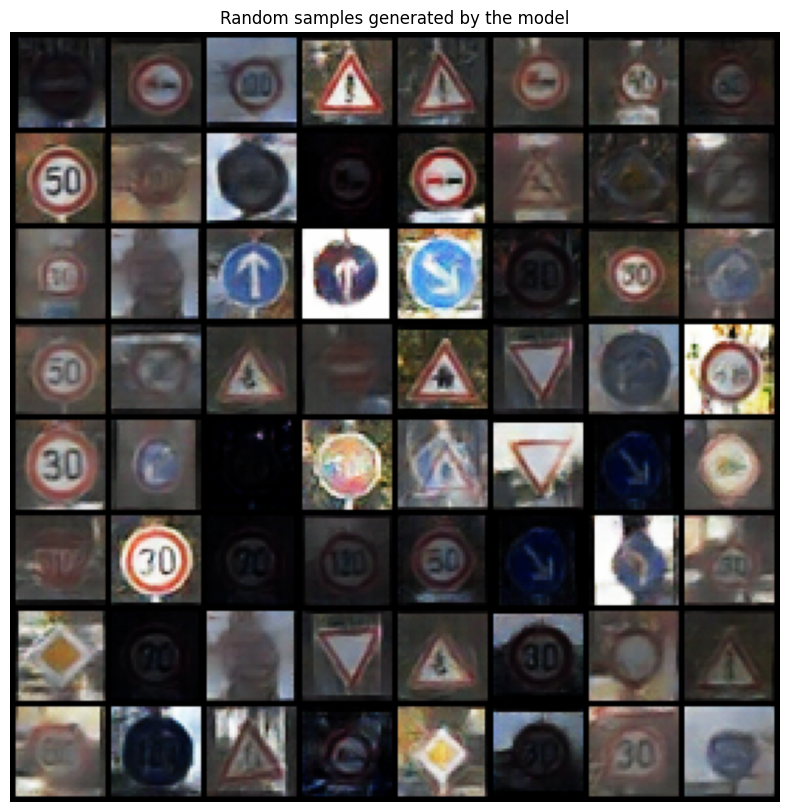

In [ ]:
loaded_imgs = torch.load("sroda_Okoń.pt")

indices = torch.randint(0, len(loaded_imgs), (64,))
sample_imgs = loaded_imgs[indices]

grid = vutils.make_grid(sample_imgs, nrow=8, padding=2, normalize=False)

plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Random samples generated by the model")
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.show()